In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

np.random.seed(42)
sns.set_style("whitegrid")

### Tasks
**Task 1**: Bias Diagnosis — Case Studies
For each of the following scenarios, identify the type of bias present (selection bias, survivorship bias, measurement bias, response bias, or another relevant type), explain how it distorts the conclusions, and suggest one concrete fix.

#### Scenario A — App Review Analysis: A product team analyzes their app's reviews on the App Store to understand user satisfaction. The average rating is 4.3/5, so they conclude that most users are happy. They plan to reduce investment in customer support.

**Selection Bias**

Explanation: Only users who choose to leave a review are included, and they are often either extremely satisfied or extremely dissatisfied. This overrepresents positive reviewers and does not reflect the satisfaction of all users.

Fix: Collect feedback from a random sample of all users, for example via in-app prompts or follow-up surveys, to ensure representation across the entire user base.

#### Scenario B — Startup Success Study: A business school studies 200 successful tech startups (all founded in the last 10 years and still operating) to identify common traits that predict startup success. They find that 80% had a pivot in their first two years and conclude that pivoting is a key success strategy.

**Survivorship Bias**

Explanation: The study only includes startups that survived and are currently successful. Failed startups, which may not have pivoted or had other characteristics, are excluded, skewing the results. This leads to overestimating the importance of pivoting for success.

Fix: Include startups that failed in the dataset to compare characteristics of both successful and unsuccessful companies.

#### Scenario C — Health Survey: A health organization sends a voluntary online survey to 50,000 email subscribers asking about exercise habits and health outcomes. The survey receives 5,000 responses (10% response rate). Results show that respondents exercise an average of 5 hours per week and have excellent self-reported health.

**Response Bias / Voluntary Response Bias** 

Explanation: Only 10% of recipients responded, and those who respond to health surveys are typically more health-conscious. This inflates reported exercise hours and health outcomes.

Fix: Use random sampling and follow-up reminders to increase response rate, or weight responses to adjust for differences between respondents and the overall population.

#### Scenario D — Salary Benchmarking: A recruiting platform publishes average salaries by job title based on user-submitted salary data. The platform is popular among tech workers in large cities. A company in a small town uses this data to set their salary bands.

**Selection Bias / Non-representative Sample**

Explanation: Salary data comes mainly from tech workers in large cities, which does not represent workers in smaller towns or other industries. Using these averages for a small-town company will likely overestimate salaries.

Fix: Collect salary data from a representative sample across locations, industries, and company sizes, or adjust the reported averages using weighting for geographic and industry differences.

Write your analysis in markdown cells — no code required for this task. Aim for 3–5 sentences per scenario.



### Task 2: Create the Population
Before you can study sampling, you need a known population to sample from.

Generate a synthetic population of 100,000 individuals with the following columns:
age: integers drawn from a realistic distribution (e.g., a clipped normal centered at 40 with SD of 15, range 18–85).

income: correlated with age — use a linear relationship with noise (e.g., income = 1500 * age + normal_noise). Clip to a realistic range (e.g., 15,000–250,000).

satisfaction: a score from 1–10 that depends on income (higher income → slightly higher satisfaction, with plenty of noise).

region: categorical — randomly assign "Urban" (60%), "Suburban" (25%), "Rural" (15%).

Compute and store the true population parameters: mean age, mean income, mean satisfaction, and the proportion in each region.

Display the population summary and a grid of histograms (one per numerical variable).
These population parameters are your ground truth — everything in the following tasks is measured against them.

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
sns.set_style("whitegrid")

N=100_000

In [29]:
age = np.clip(np.random.normal(loc=40, scale=15, size=N), 18, 85).astype(int)

income = np.clip(1500 * age + np.random.normal(0, 20_000, N), 15_000, 250_000)

satisfaction = np.clip((income / income.max()) * 10 + np.random.normal(0, 2, N), 1, 10)

regions = np.random.choice(["Urban", "Suburban", "Rural"], size=N, p=[0.6, 0.25, 0.15])

In [30]:
population = pd.DataFrame({
    "age": age,
    "income": income,
    "satisfaction": satisfaction,
    "region": regions
})

In [31]:
pop_mean_age=population["age"].mean()
pop_mean_income=population["income"].mean()
pop_mean_satisfaction=population["satisfaction"].mean()
pop_region_counts = population["region"].value_counts(normalize=True)

In [32]:
print("Population Parameters:")
print(f"Mean Age: {pop_mean_age:.2f}")
print(f"Mean Income: {pop_mean_income:.2f}")
print(f"Mean Satisfaction: {pop_mean_satisfaction:.2f}")
print("\nProportion by Region:")
print(pop_region_counts)

Population Parameters:
Mean Age: 40.02
Mean Income: 60675.27
Mean Satisfaction: 3.58

Proportion by Region:
region
Urban       0.59927
Suburban    0.25075
Rural       0.14998
Name: proportion, dtype: float64


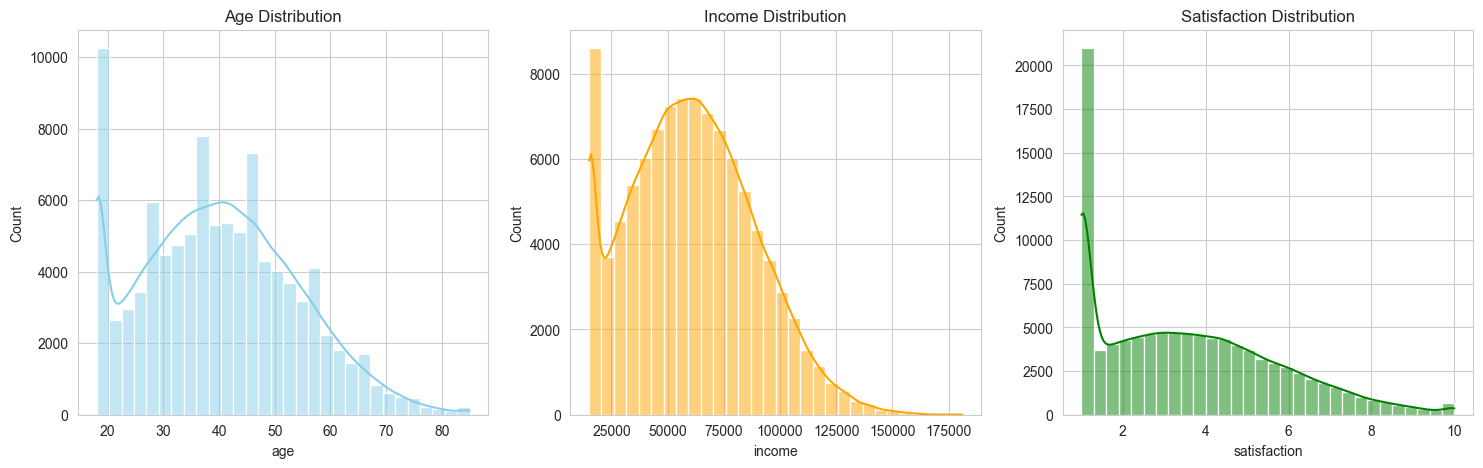

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(population["age"], bins=30, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title("Age Distribution")
sns.histplot(population["income"], bins=30, kde=True, ax=axes[1], color='orange')
axes[1].set_title("Income Distribution")
sns.histplot(population["satisfaction"], bins=30, kde=True, ax=axes[2], color='green')
axes[2].set_title("Satisfaction Distribution")
plt.show()

### Task 3: Biased vs. Unbiased Sampling
Draw samples from your population using three different strategies and compare how well each recovers the true population parameters.

Simple random sample (n = 200): every individual has an equal chance of being selected.
Biased sample — Urban only (n = 200): only sample from individuals in the "Urban" region.
Biased sample — High-income filter (n = 200): only sample from individuals with income above the population median.
For each sample:

Compute mean age, mean income, and mean satisfaction.
Display the results alongside the true population parameters in a comparison table.
Create overlapping KDE plots (sample vs. population) for income and satisfaction.
Now, repeat each sampling strategy 1,000 times and collect the sample means:

Plot the sampling distribution of the mean income for each strategy (three histograms, side by side).

Mark the true population mean on each histogram.

Guiding question: Which sampling strategies produce biased estimates? How can you tell from the sampling distributions?

In [46]:
#step 1
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

np.random.seed(42)

In [47]:
srs=population.sample(200,random_state=42)
urban_only = population[population['region'] == "Urban"].sample(200, random_state=42)
high_income = population[population['income'] > population['income'].median()].sample(200, random_state=42)

In [48]:
#step2
def compute_stats(df):
    return pd.Series({
        'mean_age': df['age'].mean(),
        'mean_income': df['income'].mean(),
        'mean_satisfaction': df['satisfaction'].mean()
    })

In [49]:
stats_table = pd.DataFrame({
    'Population': compute_stats(population),
    'SimpleRandom': compute_stats(srs),
    'UrbanOnly': compute_stats(urban_only),
    'HighIncome': compute_stats(high_income)
}).T

print("Comparison of sample statistics vs. population:\n")
print(stats_table)

Comparison of sample statistics vs. population:

              mean_age   mean_income  mean_satisfaction
Population    40.02052  60675.269282           3.575768
SimpleRandom  40.29000  62424.166688           3.622787
UrbanOnly     39.70000  60492.592799           3.662156
HighIncome    49.41500  85726.042242           4.561999


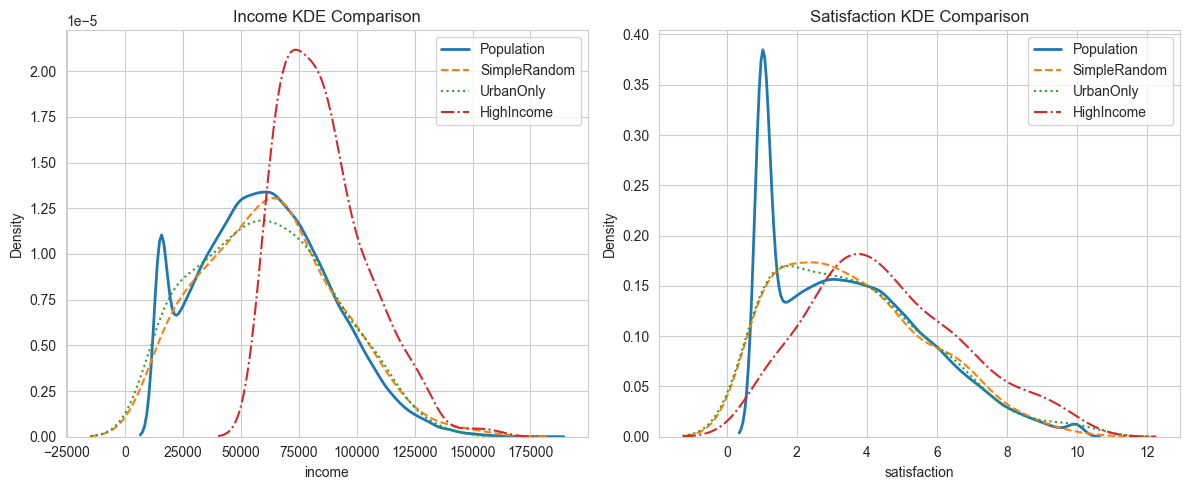

In [50]:
#Step3
plt.figure(figsize=(12,5))
for i, col in enumerate(['income','satisfaction']):
    plt.subplot(1,2,i+1)
    sns.kdeplot(population[col], label='Population', linewidth=2)
    sns.kdeplot(srs[col], label='SimpleRandom', linestyle='--')
    sns.kdeplot(urban_only[col], label='UrbanOnly', linestyle=':')
    sns.kdeplot(high_income[col], label='HighIncome', linestyle='-.')
    plt.title(f'{col.title()} KDE Comparison')
    plt.legend()
plt.tight_layout()
plt.show()

In [51]:
# --- Step 4: Repeat sampling 1,000 times ---
n_sim = 1000
mean_income_srs = []
mean_income_urban = []
mean_income_high = []

for _ in range(n_sim):
    mean_income_srs.append(population.sample(200)['income'].mean())
    mean_income_urban.append(population[population['region']=="Urban"].sample(200)['income'].mean())
    mean_income_high.append(population[population['income']>population['income'].median()].sample(200)['income'].mean())


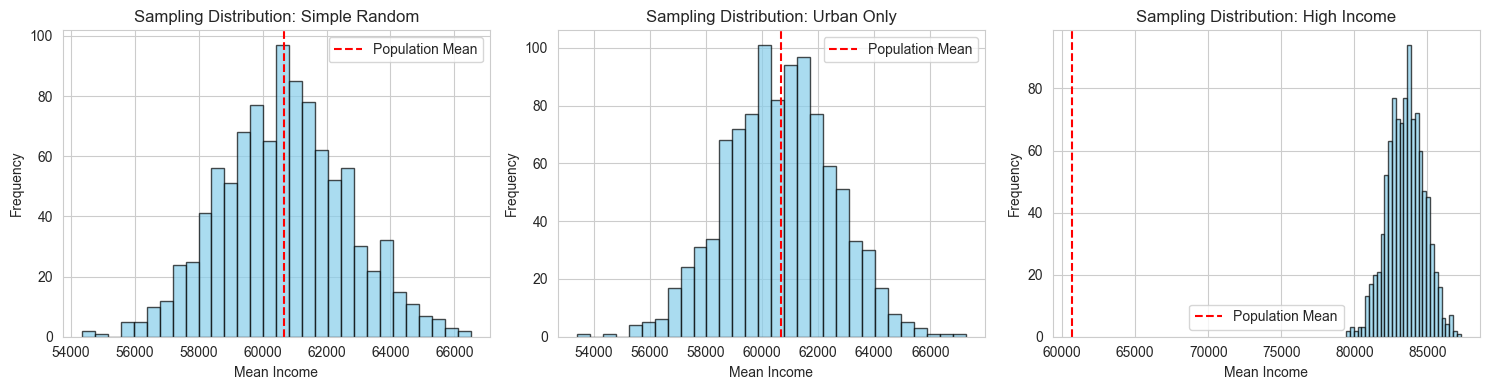

In [52]:
# --- Step 5: Plot sampling distributions ---
plt.figure(figsize=(15,4))

for i, (data, title) in enumerate(zip([mean_income_srs, mean_income_urban, mean_income_high],
                                      ['Simple Random', 'Urban Only', 'High Income'])):
    plt.subplot(1,3,i+1)
    plt.hist(data, bins=30, alpha=0.7, color='skyblue', edgecolor='black')
    plt.axvline(population['income'].mean(), color='red', linestyle='--', label='Population Mean')
    plt.title(f'Sampling Distribution: {title}')
    plt.xlabel('Mean Income')
    plt.ylabel('Frequency')
    plt.legend()

plt.tight_layout()
plt.show()

### Explanation

Simple Random Sample (SRS): Every individual has an equal chance. Histogram centers around the true population mean → unbiased.

Urban Only: Only urban residents are sampled. Income and satisfaction are likely higher than the population → biased.

High-Income Filter: Only people above median income are sampled → biased, histogram shifts to the right.

Repeating 1,000 times shows sampling variability: the spread of sample means, even when unbiased.

KDE plots visually show how each sample distribution compares to the population.